# Toy sandbox: noise-injection mechanisms

A miniature of the real pipeline where the ground truth is known, for testing
degradation mechanisms **without touching the real analysis**. Everything here
is a linear-Gaussian universe solved with least squares (what MSE training
converges to for a linear problem), plus an optional MLP check at the end that
uses the real `SimpleMLP`.

Findings this notebook reproduces (session of 2026-07-16):
- **current** (noise at train, no renorm, clean val): the signal component of
  the training input is identical to the val input, so the noisy channel's val
  contribution shrinks by the reliability `1/(1+σ²)` — the diminished
  dependence the network could learn. Robust degradation. **This is what the
  real pipeline does, on purpose.**
- **renorm** (noise + renormalize at train, clean val): learns the *identical*
  mapping, but validation feeds a signal `sqrt(1+σ²)`× stronger than trained
  on. Suppression weakens to `1/sqrt(1+σ²)` and never reaches the floor.
  Rejected.
- **noise/mix at both** train and val: answers a different question ("how much
  information does a genuinely noisier measurement carry"). Also reaches the
  floor; useful as a robustness check.

In [72]:
import numpy as np
import matplotlib.pyplot as plt

def nrm(a):
    return (a - a.mean(0)) / a.std(0)

def r2(y, p):
    return 1 - ((y - p)**2).sum() / ((y - y.mean())**2).sum()

def fit_linear(X, y):
    A = np.hstack([X, np.ones((len(X), 1))])
    W, *_ = np.linalg.lstsq(A, y, rcond=None)
    return W

def predict(W, X):
    return np.hstack([X, np.ones((len(X), 1))]) @ W

## The toy universe

One parameter θ, two observables. O₁ is a noisier view of θ than O₂, so
degrading O₂ should hand the model off to O₁ and R² should fall to the
"O₁ alone" floor. Change the two view noises to explore other regimes.

In [73]:
N, NV = 40_000, 8_000            # total sims, validation size
VIEW_NOISE_O1 = 0.80             # O1 is the weaker observable
VIEW_NOISE_O2 = 0.20             # O2 is the stronger one (the one we degrade)

rng = np.random.default_rng(0)
theta = rng.normal(size=N)
x1 = nrm((theta + VIEW_NOISE_O1 * rng.normal(size=N)).reshape(-1, 1))
x2 = nrm((theta + VIEW_NOISE_O2 * rng.normal(size=N)).reshape(-1, 1))
tr, va = slice(0, N - NV), slice(N - NV, N)

## The mechanisms

Each mechanism maps the clean normalized observable to a (train version,
val version) pair. To try a new one, add a function here and a line in
`MECHANISMS` — nothing else changes.

In [74]:
def mech_current(x, nl, rng):
    """Real pipeline: noise at train, NO renormalize, clean validation."""
    return x + rng.normal(0, nl, x.shape), x

def mech_renorm(x, nl, rng):
    """Rejected: renormalize after the noise, clean validation."""
    return nrm(x + rng.normal(0, nl, x.shape)), x

def mech_noise_both(x, nl, rng):
    """Noise + renormalize at train AND val (fresh noise each)."""
    return nrm(x + rng.normal(0, nl, x.shape)), nrm(x + rng.normal(0, nl, x.shape))

def mech_mix_both(x, nl, rng):
    """Variance-preserving mix at both: z = sqrt(1-a)x + sqrt(a)e, Var(z)=1 exactly."""
    a = nl**2 / (1 + nl**2)
    mix = lambda: np.sqrt(1 - a) * x + np.sqrt(a) * rng.normal(size=x.shape)
    return mix(), mix()

MECHANISMS = {
    "current":    (mech_current,    "#D85A30", "-"),
    "renorm":     (mech_renorm,     "#185FA5", "-"),
    "noise_both": (mech_noise_both, "#1D9E75", "--"),
    "mix_both":   (mech_mix_both,   "#534AB7", "-"),
}

def run_mechanism(mech, nl, rng):
    """Train on [x1, degraded x2], evaluate on the val split. Returns R2, |w(O2)|."""
    z2_tr, z2_va = mech(x2, nl, rng)
    W = fit_linear(np.hstack([x1[tr], z2_tr[tr]]), theta[tr])
    p = predict(W, np.hstack([x1[va], z2_va[va]]))
    return r2(theta[va], p), abs(W[1])

## Experiment 1 — which mechanisms reach the floor?

The floor is the O₁-alone R²: where the model *should* land once O₂ carries
nothing. A mechanism that plateaus above the floor is not fully degrading.

In [75]:
rng = np.random.default_rng(1)
W_floor = fit_linear(x1[tr], theta[tr])
floor = r2(theta[va], predict(W_floor, x1[va]))
W_ceil = fit_linear(np.hstack([x1[tr], x2[tr]]), theta[tr])
ceil = r2(theta[va], predict(W_ceil, np.hstack([x1[va], x2[va]])))
print(f"O1-alone floor R² = {floor:.3f}    both-clean ceiling R² = {ceil:.3f}")

NOISE_LEVELS = [0, 0.25, 0.5, 0.75, 1, 1.5, 2, 2.5, 3.5, 5, 7, 10]
results = {name: [run_mechanism(m, nl, rng) for nl in NOISE_LEVELS]
           for name, (m, _, _) in MECHANISMS.items()}

O1-alone floor R² = 0.627    both-clean ceiling R² = 0.964


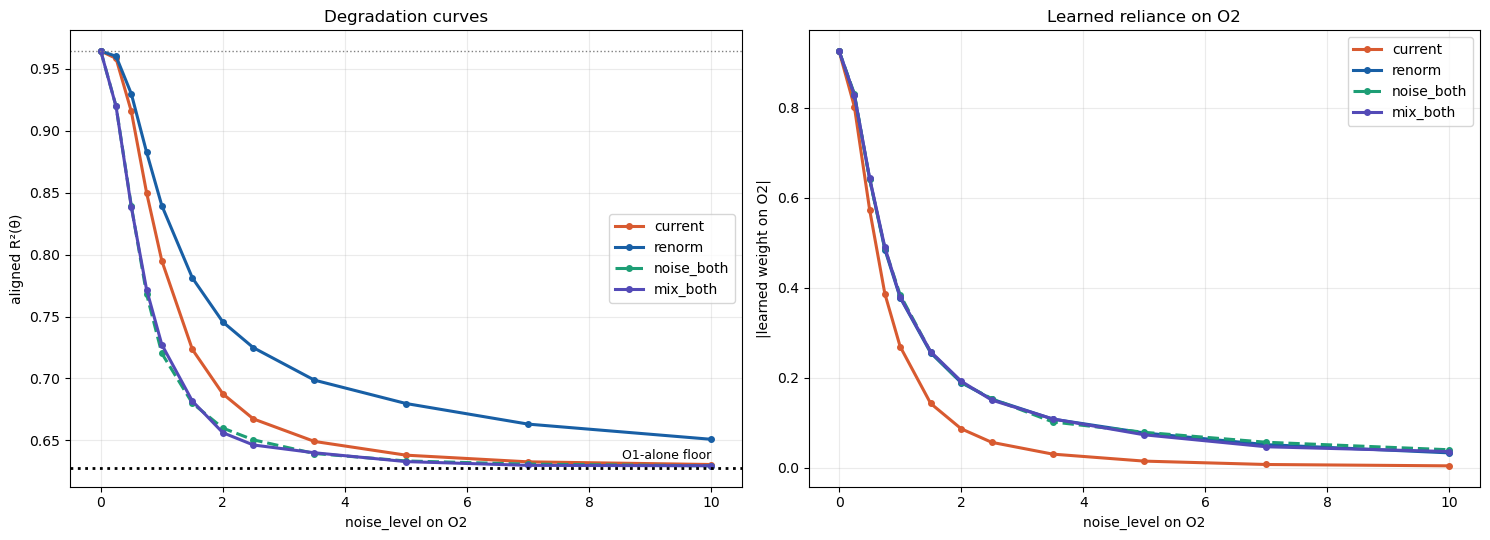

current      R² at max noise: 0.631   gap above floor: +0.003
renorm       R² at max noise: 0.651   gap above floor: +0.023
noise_both   R² at max noise: 0.629   gap above floor: +0.002
mix_both     R² at max noise: 0.630   gap above floor: +0.002


In [76]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(15, 5.5))
for name, (m, color, ls) in MECHANISMS.items():
    a1.plot(NOISE_LEVELS, [v[0] for v in results[name]], ls, color=color, lw=2.2, marker="o", ms=4, label=name)
    a2.plot(NOISE_LEVELS, [v[1] for v in results[name]], ls, color=color, lw=2.2, marker="o", ms=4, label=name)
a1.axhline(floor, color="k", ls=":", lw=2)
a1.text(max(NOISE_LEVELS), floor + 0.005, "O1-alone floor", ha="right", va="bottom", fontsize=9)
a1.axhline(ceil, color="gray", ls=":", lw=1)
a1.set_xlabel("noise_level on O2"); a1.set_ylabel("aligned R²(θ)")
a1.set_title("Degradation curves"); a1.legend(); a1.grid(alpha=0.25)
a2.set_xlabel("noise_level on O2"); a2.set_ylabel("|learned weight on O2|")
a2.set_title("Learned reliance on O2"); a2.legend(); a2.grid(alpha=0.25)
plt.tight_layout()
plt.show()

for name in MECHANISMS:
    gap = results[name][-1][0] - floor
    print(f"{name:<12} R² at max noise: {results[name][-1][0]:.3f}   gap above floor: {gap:+.3f}")

## Aside — a noisy-enough observable's *conditional* distribution matches the prior

The weight-decay columns above (and the table in Experiment 2 below) already show
the fitted slope `w(σ) → 0` as noise grows. Same fact, seen as a distribution
instead of a point estimate: split O2 by an extreme reading into low/high groups
and compare θ's histogram *within* each group to θ's overall (prior) histogram.
At low noise the groups clearly differ — O2 carries real information about θ. At
very high noise the groups become indistinguishable from the prior — conditioning
on a sufficiently noisy observable does nothing, because `w→0` means the
best-fit prediction has collapsed to the prior mean and O2 has stopped
discriminating between θ values at all.

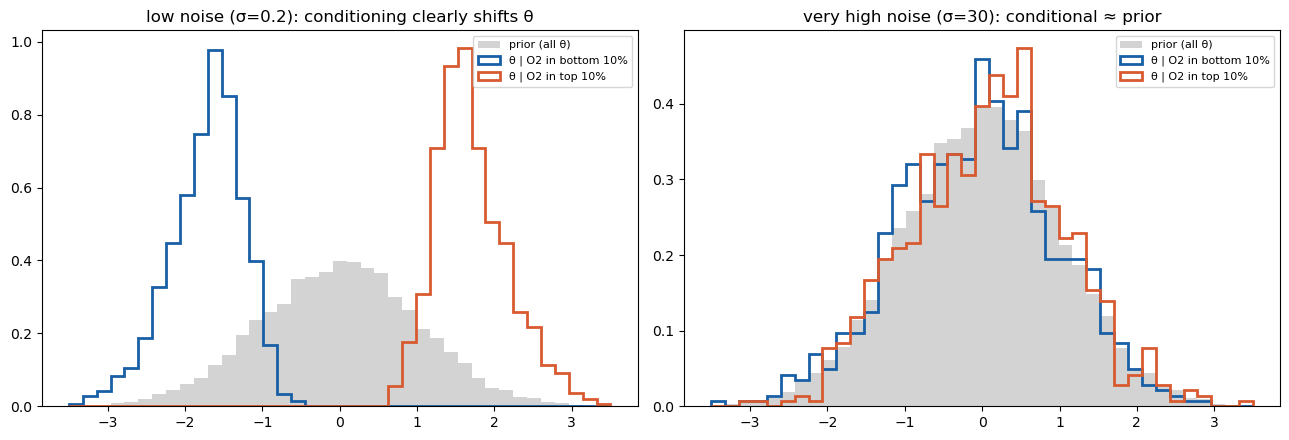

In [77]:
def group_hist(nl, ax, title):
    z, _ = mech_current(x2, nl, np.random.default_rng(3))
    q1, q3 = np.quantile(z[va], [0.1, 0.9])
    lo, hi = theta[va][z[va, 0] < q1], theta[va][z[va, 0] > q3]
    bins = np.linspace(-3.5, 3.5, 40)
    ax.hist(theta[va], bins=bins, density=True, color="lightgray", label="prior (all θ)")
    ax.hist(lo, bins=bins, density=True, histtype="step", color="#185FA5", lw=2, label="θ | O2 in bottom 10%")
    ax.hist(hi, bins=bins, density=True, histtype="step", color="#D85A30", lw=2, label="θ | O2 in top 10%")
    ax.set_title(title); ax.legend(fontsize=8)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
group_hist(0.2, a1, "low noise (σ=0.2): conditioning clearly shifts θ")
group_hist(30, a2, "very high noise (σ=30): conditional ≈ prior")
plt.tight_layout()
plt.show()

## Experiment 2 — the two clean-val schemes learn the *same* mapping

`w_current × sqrt(1+σ²) = w_renorm` at every noise level: renormalizing only
changes the units of the weight. What differs is that renorm's validation
feeds that weight a signal `sqrt(1+σ²)`× stronger than it was calibrated on —
which is exactly why its degradation is weak.

In [78]:
rng = np.random.default_rng(2)
print(f"{'noise':<8}{'w_current':>12}{'x sqrt(1+s^2)':>16}{'w_renorm':>12}")
for nl in [0.5, 1, 2.5, 5, 10]:
    _, w_cur = run_mechanism(mech_current, nl, np.random.default_rng(42))
    _, w_ren = run_mechanism(mech_renorm, nl, np.random.default_rng(42))
    print(f"{nl:<8}{w_cur:>12.4f}{w_cur*np.sqrt(1+nl**2):>16.4f}{w_ren:>12.4f}")

noise      w_current   x sqrt(1+s^2)    w_renorm
0.5           0.5744          0.6422      0.6435
1             0.2686          0.3799      0.3813
2.5           0.0573          0.1542      0.1549
5             0.0152          0.0777      0.0780
10            0.0040          0.0399      0.0401


## Experiment 3 — shuffle signatures across ten categories

Construct each category from known ground truth (M1/M2 choose which parameter
combinations each observable sees), then run the pipeline's exact shuffle
procedure:
- **S₁**: scramble O₂, truths stay with O₁ → R² survives iff the model reads O₁
- **S₂**: scramble O₂ and truths together → R² survives iff the model reads O₂

Off the S₁=S₂ diagonal = asymmetric reliance. Along it, position separates
synergy (0,0) from redundancy (+,+). Cases 4, 5, and 7 all coincide at the
origin — only the aligned R² tells them apart (Case 7 shows that "both
observables get a positive weight" does NOT imply a redundancy signature:
if the weights combine to cancel a shared confound rather than adding two
independent channels, shuffling destroys the cancellation and collapses to
the same (0,0) point as true synergy). Cases 9 and 10 are further caveats:
Case 9 shows a low-ceiling "parallel" confound can still look like clean
single-observable reliance; Case 10 shows that structural redundancy
(identical to Case 6) can be disguised as "no information" purely by making
one observable noisier than its partner. Note R² has no floor at 0: an
uncorrelated but variable prediction scores −1 or worse.

category                            aligned      S1      S2
Case 1 single, no gain                 0.92    0.92   -0.89
Case 2 single, improves                0.85   -0.47   -2.15
Case 3 both, better                    0.85    0.39   -2.10
Case 4 only combined                   0.96    0.01    0.01
Case 5 no information                 -0.00   -0.00   -0.00
Case 6 both, no gain                   0.96    0.44    0.45
Case 7 symmetric complementary         0.91    0.01    0.01
Case 8 asymmetric complementary        0.89    0.01   -0.30
Case 9 parallel confound               0.48    0.39   -0.00
Case 10 asymmetric reliability         0.98    0.97   -0.79


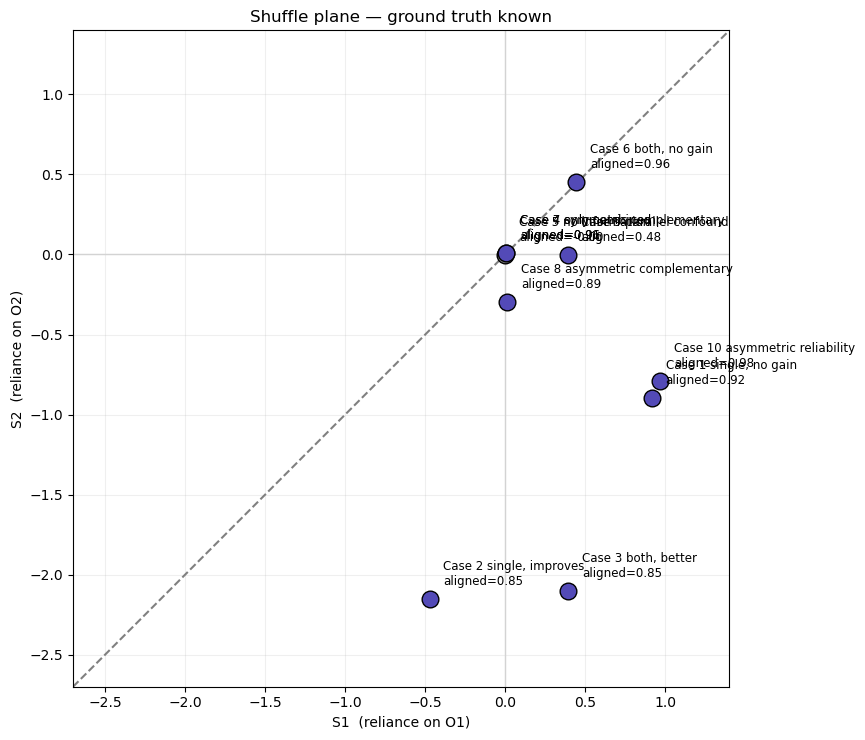

In [79]:
def shuffle_signature(M1, M2, view_noise=0.3, seed=0):
    """Aligned R², S1, S2 for theta_1, given each observable's view M of theta.
    view_noise is a shared std, or a (noise_O1, noise_O2) pair for asymmetric SNR."""
    g = np.random.default_rng(seed)
    th = g.normal(size=(N, 2))
    vn1, vn2 = view_noise if isinstance(view_noise, tuple) else (view_noise, view_noise)
    o1 = th @ np.atleast_2d(M1).T + vn1 * g.normal(size=(N, np.atleast_2d(M1).shape[0]))
    o2 = th @ np.atleast_2d(M2).T + vn2 * g.normal(size=(N, np.atleast_2d(M2).shape[0]))
    X, n1 = np.hstack([o1, o2]), o1.shape[1]
    W = fit_linear(X[tr], th[tr])
    Xv, thv = X[va], th[va]
    perm = g.permutation(len(Xv))
    Xs = Xv.copy(); Xs[:, n1:] = Xv[perm, n1:]          # scramble O2 only
    A  = r2(thv[:, 0], predict(W, Xv)[:, 0])
    S1 = r2(thv[:, 0], predict(W, Xs)[:, 0])            # truths stay with O1
    S2 = r2(thv[perm, 0], predict(W, Xs)[:, 0])         # truths follow O2
    return A, S1, S2

CATEGORIES = {
    "Case 1 single, no gain":           ([[1, 0], [0, 1]], [[0, 0]],         0.3),
    "Case 2 single, improves":          ([[1, 1]],         [[0, 1]],         0.3),
    "Case 3 both, better":              ([[1, 0.5]],       [[0.5, 1]],       0.3),
    "Case 4 only combined":             ([[1, 1]],         [[1, -1]],        0.3),
    "Case 5 no information":            ([[0, 0]],         [[0, 0]],         0.3),
    "Case 6 both, no gain":             ([[1, 0], [0, 1]], [[1, 0], [0, 1]], 0.3),
    "Case 7 symmetric complementary":   ([[0.7, 0.7]],     [[0.7, -0.7]],    0.3),
    "Case 8 asymmetric complementary":  ([[0.7, 0.7]],     [[0.5, -0.7]],    0.3),
    "Case 9 parallel confound":         ([[1, 1]],         [[0.6, 0.6]],     0.3),
    "Case 10 asymmetric reliability":   ([[1, 0], [0, 1]], [[1, 0], [0, 1]], (0.15, 0.6)),
}

fig, ax = plt.subplots(figsize=(8.5, 7.5))
lim = (-2.7, 1.4)
ax.plot(lim, lim, color="gray", ls="--", lw=1.5)
ax.axhline(0, color="lightgray", lw=1); ax.axvline(0, color="lightgray", lw=1)
print(f"{'category':<34}{'aligned':>9}{'S1':>8}{'S2':>8}")
for name, (M1, M2, vn) in CATEGORIES.items():
    A, S1, S2 = shuffle_signature(M1, M2, view_noise=vn)
    dead = abs(A) < 0.1
    ax.plot(S1, S2, "o", ms=12, color="gray" if dead else "#534AB7", mec="k")
    ax.annotate(f"{name}\naligned={A:.2f}", (S1, S2), xytext=(10, 10),
                textcoords="offset points", fontsize=8.5)
    print(f"{name:<34}{A:>9.2f}{S1:>8.2f}{S2:>8.2f}")
ax.set_xlabel("S1  (reliance on O1)"); ax.set_ylabel("S2  (reliance on O2)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.grid(alpha=0.2)
ax.set_title("Shuffle plane — ground truth known")
plt.tight_layout()
plt.show()

## Experiment 4 — nonlinear relationships and degeneracies

Everything above is a *linear* recipe: `M1`/`M2` mix θ1,θ2 linearly, and
`fit_linear` can only ever find a linear combination. That's blind by
construction to a whole class of real degeneracies — an observable that depends
on a **product** or a **square** of the parameters carries real information but
zero *linear* correlation with either parameter alone (for a symmetric prior,
`Cov(θ, θ²) = E[θ³] = 0` and `Cov(θ1, θ1·θ2) = E[θ1²]E[θ2] = 0`). Two cases:

- **Case A — product/sum degeneracy** (resolvable in principle): `O1 = θ1·θ2`,
  `O2 = θ1+θ2`. Knowing both the sum and the product of two numbers determines
  them — they're the two roots of `x² − (sum)x + (product) = 0` — but reading
  off *which* root is θ1 is a genuine two-fold (θ1↔θ2 swap) ambiguity that nothing
  here resolves.
- **Case B — magnitude/sign degeneracy** (does NOT resolve a confound): `O1 = θ1²`
  carries real information (about `|θ1|`), but it's information along a
  completely different axis than O2's θ2-confound, so it can't help resolve it.

In [80]:
sigma = 0.3
g = np.random.default_rng(7)
th2 = g.normal(size=(N, 2))
t1, t2 = th2[:, 0], th2[:, 1]

print("=== Case A: O1 = t1*t2 (product), O2 = t1+t2 (sum) ===")
oA1 = (t1 * t2 + sigma * g.normal(size=N)).reshape(-1, 1)
oA2 = (t1 + t2 + sigma * g.normal(size=N)).reshape(-1, 1)

W1 = fit_linear(oA1[tr], t1[tr]);  print(f"solo O1 (product) linear R²:       {r2(t1[va], predict(W1, oA1[va])):.3f}")
W2 = fit_linear(oA2[tr], t1[tr]);  print(f"solo O2 (sum) linear R²:           {r2(t1[va], predict(W2, oA2[va])):.3f}")
XA = np.hstack([oA1, oA2])
WA = fit_linear(XA[tr], t1[tr]);   print(f"joint LINEAR [O1,O2] R²:           {r2(t1[va], predict(WA, XA[va])):.3f}   (weight on O1 = {WA[0]:+.3f} — ~0, linearly blind)")

s, p = oA2[:, 0], oA1[:, 0]                       # plug the noisy readings into the quadratic formula
disc = np.clip(s**2 - 4*p, 0, None)                # clip: noise can push the true discriminant negative
r_plus, r_minus = (s + np.sqrt(disc))/2, (s - np.sqrt(disc))/2
oracle = np.where(np.abs(r_plus - t1) < np.abs(r_minus - t1), r_plus, r_minus)   # cheats: picks the root closest to truth
naive = r_plus                                     # a real estimator with no way to break the swap ambiguity
print(f"quadratic-formula ORACLE R² (upper bound, cheats on the sign): {r2(t1[va], oracle[va]):.3f}")
print(f"quadratic-formula NAIVE  R² (always the '+' root):            {r2(t1[va], naive[va]):.3f}")

print()
print("=== Case B: O1 = t1^2 (magnitude), O2 = t1+t2 (confound) ===")
oB1 = (t1**2 + sigma * g.normal(size=N)).reshape(-1, 1)
oB2 = (t1 + t2 + sigma * g.normal(size=N)).reshape(-1, 1)

W1b  = fit_linear(oB1[tr], t1[tr]);      print(f"solo O1 (t1^2) linear R² for t1:        {r2(t1[va], predict(W1b, oB1[va])):.3f}")
W1b2 = fit_linear(oB1[tr], (t1**2)[tr]); print(f"solo O1 (t1^2) linear R² for t1^2 itself: {r2((t1**2)[va], predict(W1b2, oB1[va])):.3f}  (real info, wrong axis)")
W2b  = fit_linear(oB2[tr], t1[tr]);      print(f"solo O2 (confound) linear R² for t1:    {r2(t1[va], predict(W2b, oB2[va])):.3f}")
XB = np.hstack([oB1, oB2])
WB = fit_linear(XB[tr], t1[tr]);         print(f"joint LINEAR [O1,O2] R² for t1:         {r2(t1[va], predict(WB, XB[va])):.3f}   (weight on O1 = {WB[0]:+.3f} — adding O1 buys nothing)")

=== Case A: O1 = t1*t2 (product), O2 = t1+t2 (sum) ===
solo O1 (product) linear R²:       -0.000
solo O2 (sum) linear R²:           0.478
joint LINEAR [O1,O2] R²:           0.478   (weight on O1 = -0.005 — ~0, linearly blind)
quadratic-formula ORACLE R² (upper bound, cheats on the sign): 0.903
quadratic-formula NAIVE  R² (always the '+' root):            -0.137

=== Case B: O1 = t1^2 (magnitude), O2 = t1+t2 (confound) ===
solo O1 (t1^2) linear R² for t1:        -0.000
solo O1 (t1^2) linear R² for t1^2 itself: 0.957  (real info, wrong axis)
solo O2 (confound) linear R² for t1:    0.475
joint LINEAR [O1,O2] R² for t1:         0.475   (weight on O1 = -0.006 — adding O1 buys nothing)


- **Case C — magnitude resolved by a noisy sign carrier**: `O1 = θ1²`
  (precise magnitude, same as Case B), `O2 = θ1 + noise(σ)` — now used only to
  *pick the sign*, not to measure θ1's value. Unlike Case B, here O2's
  degeneracy axis (sign) is exactly what O1 is missing — so this is the
  "resolves" counterpart to Case B, *if* O2 is reliable enough.
- **Case E — periodic (many-fold) degeneracy**: `O1 = sin(4·θ1)`, `O2 = θ1 +
  noise(σ)` used to pick which of several candidate branches (`sin` repeats
  every `2π/4 ≈ 1.57`, so θ1's `±4` support spans ~5 periods) is correct.
  Same mechanism as Case C, but with many candidate branches instead of two
  candidate signs — a strictly harder disambiguation problem.

In [81]:
print()
print("=== Case C: O1 = t1^2 (precise magnitude), O2 = t1 + noise(sign_noise) ===")
SIGN_NOISE = [0.3, 0.5, 0.8, 1.0, 1.3, 1.6, 2.0, 3.0]
caseC_solo, caseC_nl = [], []
for sn in SIGN_NOISE:
    oC1 = t1**2 + sigma * g.normal(size=N)
    oC2 = t1 + sn * g.normal(size=N)
    W2c = fit_linear(oC2[tr, None], t1[tr])
    caseC_solo.append(r2(t1[va], predict(W2c, oC2[va, None])))
    mag_hat, sign_hat = np.sqrt(np.clip(oC1, 0, None)), np.sign(oC2)
    caseC_nl.append(r2(t1[va], (sign_hat * mag_hat)[va]))
print(f"{'sign noise':<12}{'solo O2':>10}{'mag+sign':>10}")
for sn, a, b in zip(SIGN_NOISE, caseC_solo, caseC_nl):
    print(f"{sn:<12}{a:>10.3f}{b:>10.3f}")

print()
print("=== Case E: O1 = sin(4*t1) (periodic), O2 = t1 + noise(branch_noise) ===")
k, sigma_o1 = 4.0, 0.05
BRANCH_NOISE = [0.1, 0.2, 0.3, 0.4, 0.5, 0.7, 1.0, 1.2]
caseE_solo, caseE_nl = [], []
for bn in BRANCH_NOISE:
    oE1 = np.sin(k * t1) + sigma_o1 * g.normal(size=N)
    oE2 = t1 + bn * g.normal(size=N)
    W2e = fit_linear(oE2[tr, None], t1[tr])
    caseE_solo.append(r2(t1[va], predict(W2e, oE2[va, None])))
    asin_o1 = np.arcsin(np.clip(oE1, -1, 1))
    branches = []
    for n in range(-4, 5):
        branches.append((asin_o1 + 2*np.pi*n) / k)
        branches.append((np.pi - asin_o1 + 2*np.pi*n) / k)
    branches = np.stack(branches, axis=1)
    diffs = np.abs(branches - oE2[:, None])
    recon = branches[np.arange(N), np.argmin(diffs, axis=1)]
    caseE_nl.append(r2(t1[va], recon[va]))
print(f"{'branch noise':<14}{'solo O2':>10}{'sin+branch':>12}")
for bn, a, b in zip(BRANCH_NOISE, caseE_solo, caseE_nl):
    print(f"{bn:<14}{a:>10.3f}{b:>10.3f}")


=== Case C: O1 = t1^2 (precise magnitude), O2 = t1 + noise(sign_noise) ===
sign noise     solo O2  mag+sign
0.3              0.919     0.924
0.5              0.802     0.869
0.8              0.613     0.699
1.0              0.497     0.577
1.3              0.381     0.411
1.6              0.272     0.234
2.0              0.196     0.077
3.0              0.107    -0.209

=== Case E: O1 = sin(4*t1) (periodic), O2 = t1 + noise(branch_noise) ===
branch noise     solo O2  sin+branch
0.1                0.990     0.996
0.2                0.961     0.976
0.3                0.918     0.929
0.4                0.863     0.844
0.5                0.800     0.708
0.7                0.677     0.440
1.0                0.503    -0.089
1.2                0.415    -0.571


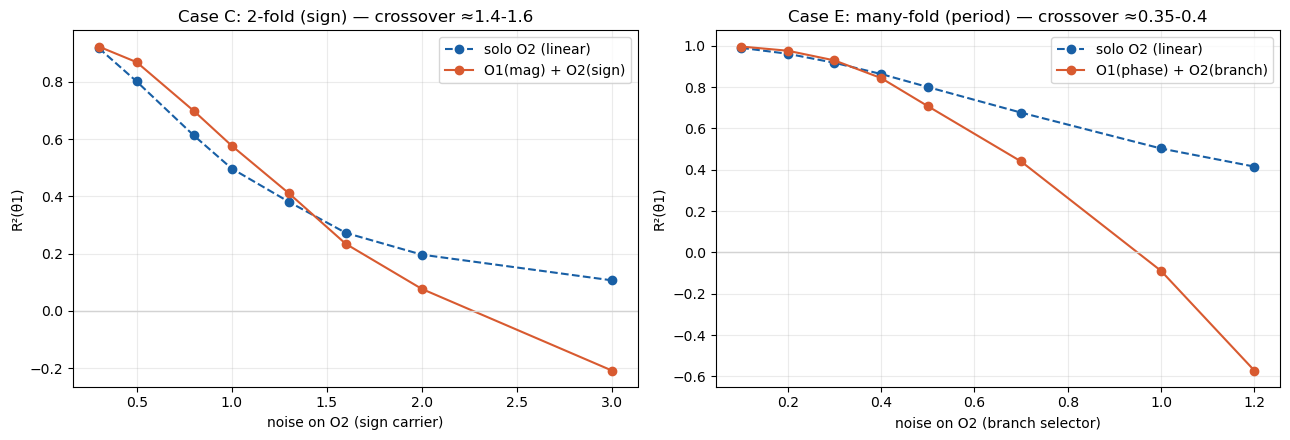

In [82]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.5))
a1.plot(SIGN_NOISE, caseC_solo, "o--", color="#185FA5", label="solo O2 (linear)")
a1.plot(SIGN_NOISE, caseC_nl, "o-", color="#D85A30", label="O1(mag) + O2(sign)")
a1.axhline(0, color="lightgray", lw=1)
a1.set_xlabel("noise on O2 (sign carrier)"); a1.set_ylabel("R²(θ1)")
a1.set_title("Case C: 2-fold (sign) — crossover ≈1.4-1.6"); a1.legend(); a1.grid(alpha=0.25)

a2.plot(BRANCH_NOISE, caseE_solo, "o--", color="#185FA5", label="solo O2 (linear)")
a2.plot(BRANCH_NOISE, caseE_nl, "o-", color="#D85A30", label="O1(phase) + O2(branch)")
a2.axhline(0, color="lightgray", lw=1)
a2.set_xlabel("noise on O2 (branch selector)"); a2.set_ylabel("R²(θ1)")
a2.set_title("Case E: many-fold (period) — crossover ≈0.35-0.4"); a2.legend(); a2.grid(alpha=0.25)
plt.tight_layout()
plt.show()

## Filling out the taxonomy: only-one / both-clean / both-redundant

A, B, C, E all involve a genuine degeneracy in O1. Three more basic shapes,
mirroring Experiment 3's "single / both / redundant" split but for nonlinear
relationships:

- **Case F — both nonlinear, redundant, wrong axis**: `O1 = θ1²+noise`,
  `O2 = θ1²+noise` (two independent measurements of the *same* nonlinear
  feature). Nonlinear analog of Case 6 (redundancy) — except redundancy only
  pays off for the axis the observables actually measure (`θ1²`); it does
  nothing for signed θ1, which neither one carries.
- **Case G — one observable nonlinearly sufficient, other a decoy**: `O1 =
  θ1³+noise` (monotonic, invertible, no degeneracy at all) — but a *linear*
  fit only ever captures the fixed correlation `corr(θ1,θ1³)`, well below 1
  even at zero noise. `O2 = θ1+θ2` (the usual confound). Nonlinear analog of
  Case 1 (single, no gain) — with a twist, see below.
- **Case H — both required, cleanly resolved (no ambiguity)**: `O1 =
  θ1+θ2²+noise` (θ2² leaks additively into O1), `O2 = θ2+noise` (a clean,
  unambiguous read of θ2 itself). Unlike Case A's product/sum, recovering
  `θ1 = O1 − O2²` has **no residual swap or branch ambiguity** — O2 already
  tells you θ2's sign directly, squaring it introduces nothing new to
  disambiguate.

In [83]:
print("=== Case F: O1 = t1^2+noise, O2 = t1^2+noise (redundant, wrong axis) ===")
oF1 = (t1**2 + sigma * g.normal(size=N)).reshape(-1, 1)
oF2 = (t1**2 + sigma * g.normal(size=N)).reshape(-1, 1)
XF = np.hstack([oF1, oF2])
WF = fit_linear(XF[tr], t1[tr])
print(f"joint LINEAR R² for signed t1: {r2(t1[va], predict(WF, XF[va])):.3f}   (weights: {WF[:2]} — redundancy on the wrong axis buys nothing)")
WF2 = fit_linear(XF[tr], (t1**2)[tr])
print(f"joint LINEAR R² for t1² itself: {r2((t1**2)[va], predict(WF2, XF[va])):.3f}  (redundancy DOES help — for the axis it's actually about)")

print()
print("=== Case G: O1 = t1^3+noise (sufficient alone), O2 = t1+t2 (confound) ===")
oG1 = (t1**3 + 0.05 * g.normal(size=N)).reshape(-1, 1)
oG2 = (t1 + t2 + sigma * g.normal(size=N)).reshape(-1, 1)
W1g = fit_linear(oG1[tr], t1[tr]); print(f"solo O1 (t1^3) LINEAR R²:  {r2(t1[va], predict(W1g, oG1[va])):.3f}  (bounded well below 1 even though the relationship is noiseless-invertible)")
cbrt = np.cbrt(oG1[:, 0])
print(f"solo O1 (t1^3) cube-root R²: {r2(t1[va], cbrt[va]):.3f}  (the correct inverse — recovers nearly everything)")
XG = np.hstack([oG1, oG2])
WG = fit_linear(XG[tr], t1[tr])
print(f"joint LINEAR [O1,O2] R²:   {r2(t1[va], predict(WG, XG[va])):.3f}   (weights: {WG[:2]} — looks like O2 helps a lot...)")
print(f"...but residual corr(t1 - cbrt(O1), O2) = {np.corrcoef(t1 - cbrt, oG2[:,0])[0,1]:+.3f}  (once O1 is read correctly, O2 adds almost nothing)")

print()
print("=== Case H: O1 = t1+t2^2+noise (mixed confound), O2 = t2+noise (clean) ===")
oH1 = (t1 + t2**2 + sigma * g.normal(size=N)).reshape(-1, 1)
oH2 = (t2 + sigma * g.normal(size=N)).reshape(-1, 1)
W1h = fit_linear(oH1[tr], t1[tr]); print(f"solo O1 (mixed confound) linear R²: {r2(t1[va], predict(W1h, oH1[va])):.3f}")
W2h = fit_linear(oH2[tr], t1[tr]); print(f"solo O2 (clean t2) linear R² for t1: {r2(t1[va], predict(W2h, oH2[va])):.3f}  (~0, t2 ⊥ t1 as expected)")
XH = np.hstack([oH1, oH2])
WH = fit_linear(XH[tr], t1[tr])
print(f"joint LINEAR [O1,O2] R²:   {r2(t1[va], predict(WH, XH[va])):.3f}   (weight on O2 ≈{WH[1]:+.3f} — linearly blind to the O2² relationship)")
recon_H = oH1[:, 0] - oH2[:, 0]**2
print(f"nonlinear (O1 - O2²) R²:   {r2(t1[va], recon_H[va]):.3f}   (clean improvement, no branch ambiguity to pay for)")

=== Case F: O1 = t1^2+noise, O2 = t1^2+noise (redundant, wrong axis) ===
joint LINEAR R² for signed t1: -0.001   (weights: [ 0.02157939 -0.03054202] — redundancy on the wrong axis buys nothing)
joint LINEAR R² for t1² itself: 0.977  (redundancy DOES help — for the axis it's actually about)

=== Case G: O1 = t1^3+noise (sufficient alone), O2 = t1+t2 (confound) ===
solo O1 (t1^3) LINEAR R²:  0.603  (bounded well below 1 even though the relationship is noiseless-invertible)
solo O1 (t1^3) cube-root R²: 0.962  (the correct inverse — recovers nearly everything)
joint LINEAR [O1,O2] R²:   0.711   (weights: [0.14704226 0.26769667] — looks like O2 helps a lot...)
...but residual corr(t1 - cbrt(O1), O2) = +0.033  (once O1 is read correctly, O2 adds almost nothing)

=== Case H: O1 = t1+t2^2+noise (mixed confound), O2 = t2+noise (clean) ===
solo O1 (mixed confound) linear R²: 0.307
solo O2 (clean t2) linear R² for t1: 0.000  (~0, t2 ⊥ t1 as expected)
joint LINEAR [O1,O2] R²:   0.307   (weight on 

**Case A reading**: the linear fit can't see the product at all (weight ≈0,
R² unchanged from O2 alone). The oracle nonlinear reconstruction gets close to
the clean ceiling (~0.90) — the information genuinely is there — but the naive
version that can't resolve the θ1↔θ2 swap scores *worse than using nothing*
(negative R²): half the time it confidently reports the wrong parameter's value.
A resolvable nonlinear degeneracy is only actually resolved if something else
(a prior asymmetry, a third observable, ordering by convention) breaks the
swap — otherwise "the information is there" and "the model can extract it"
are two different claims.

**Case B reading**: O1 is a real, strong predictor of `t1²` (R²≈0.96) — this
is not a "no information" case like Category 5. It simply carries information
about a different degeneracy (sign/magnitude) than the one O2 suffers from
(the θ2 confound), so combining them buys nothing for recovering signed θ1.
The general lesson: "this observable carries real information" is necessary
but not sufficient for it to help with *this* parameter's *this* degeneracy —
the information has to be about the same failure mode you're trying to fix.

**Case C & E reading**: both curves cross. Below a critical disambiguator
noise, combining beats using the linear observable alone — the nonlinear
feature's precision is "unlocked" by a cheap, noisy hint about which branch/
sign it is. Above that noise, combining is actively worse than ignoring the
nonlinear feature entirely, because a wrong branch/sign pick is a large,
confident error, not a small one — the same "confidently wrong" failure as
Case A's naive reconstruction, but now continuously tunable by how reliable
the disambiguator is. Case E's crossover (~0.35-0.4) sits far below Case C's
(~1.4-1.6): more candidate branches means a much less noisy disambiguator is
needed before combining pays off — many-fold degeneracies are strictly more
fragile to resolve than 2-fold ones.

**Case F reading**: confirms the negative control. Redundancy only rescues
the axis the observables are actually measuring (`θ1²`, R² 0.96→0.98 from
combining) — it does nothing for signed θ1 (R²≈0 alone or combined), because
neither copy ever carried sign information to begin with. "More of the same
nonlinear feature" isn't the same as "a feature that resolves the degeneracy."

**Case G reading**: the deceptive case. The naive linear fit's jump from
R²=0.60 (O1 alone) to R²=0.71 (joint) *looks* like real synergy with O2 — but
it's an artifact of the linear fit failing to use O1's nonlinearity. Reading
O1 correctly (cube root) alone reaches R²≈0.96, and the leftover residual
barely correlates with O2 (≈0.02-0.07) — O2 was never actually needed. A
shuffle test run on the *linear* model would (correctly) report real reliance
on O2, because that flawed model genuinely does depend on it — the shuffle
diagnostic is honest about the model you gave it; the deeper bug is using a
linear model on a cubic relationship in the first place.

**Case H reading**: the clean counterpart to Case A. Both require O2, and
unlike Case A there is no discrete ambiguity left over — O2 already carries
θ2's sign directly, so squaring it resolves the confound outright (R² 0.31 →
0.53, no coin-flip risk). Not every "both required" nonlinear case is fragile
like Case A's swap — it depends on whether the *other* observable already
pins down the piece the nonlinearity would otherwise leave ambiguous.

## Experiment 4b — shuffle signatures for the nonlinear cases

Same S1/S2 machinery as Experiment 3 (shuffle O2, compare against the truth
unshuffled vs. permuted-with-O2), but the "model" being shuffled is now
whatever *estimator function* takes `(O1, O2) → θ1_hat` — not necessarily a
linear fit. Three honest (no peeking at ground truth) estimators:
- **Case A, linear**: plain `fit_linear` on `[O1,O2]` — same as Experiment 3.
- **Case A, naive nonlinear**: the quadratic-formula reconstruction, always
  taking the `+` root (a real, deployable estimator — no cheating).
- **Case B, linear**: `fit_linear` on `[O1,O2]` — there is no nonlinear
  variant to add, since no function of `(θ1², θ1+θ2)` can recover more about
  *signed* θ1 than O2 alone already gives (worked out above).
- **Case C, mag+sign**: one representative point from the crossover sweep
  (sign noise 0.8, comfortably in the "combining helps" regime).
- **Case E, sin+branch**: one representative point from its sweep (branch
  noise 0.2, "combining helps" regime).
- **Case F, linear**: the redundant-wrong-axis estimator — expect it to sit
  right at the origin, like Case 5.
- **Case G, linear vs cube-root-alone**: the *same* generative case scored by
  two different estimators, to show the shuffle test faithfully diagnoses
  whichever model you hand it — not some fixed property of the observables.
- **Case H, linear**: the clean-resolution case's linear (blind) view.
  The true `O1−O2²` nonlinear estimator is computed above but **not
  plotted here** — its shuffle values (S1≈−3.4, S2≈−5.4) are far off this
  plot's shared scale (squaring the shuffled O2 roughly quadruples the
  injected variance compared to a linear mismatch), which would squash
  every other point to make room for it.

The oracle from Experiment 4 (picks whichever quadratic root is closer to the
truth it's being scored against) is deliberately **excluded** here — it isn't
a fixed function of the inputs, so a shuffle test on it doesn't measure
anything real; it would just track whatever it's told to match.

case                              aligned      S1      S2
A linear (sum+product)               0.48   -0.52    0.48
A naive nonlinear (√ formula)       -0.14   -1.37   -0.29
B linear (mag+confound)              0.47   -0.52    0.47
C mag+sign (helps regime)            0.71   -1.05   -0.04
E sin+branch (helps regime)          0.98   -1.18    0.86
F linear (redundant, wrong axis)    -0.00   -0.00   -0.00
G linear (deceptive)                 0.71    0.39    0.07
G cube-root alone (true read)        0.96    0.96   -1.05
H linear (blind)                     0.31    0.31   -0.36


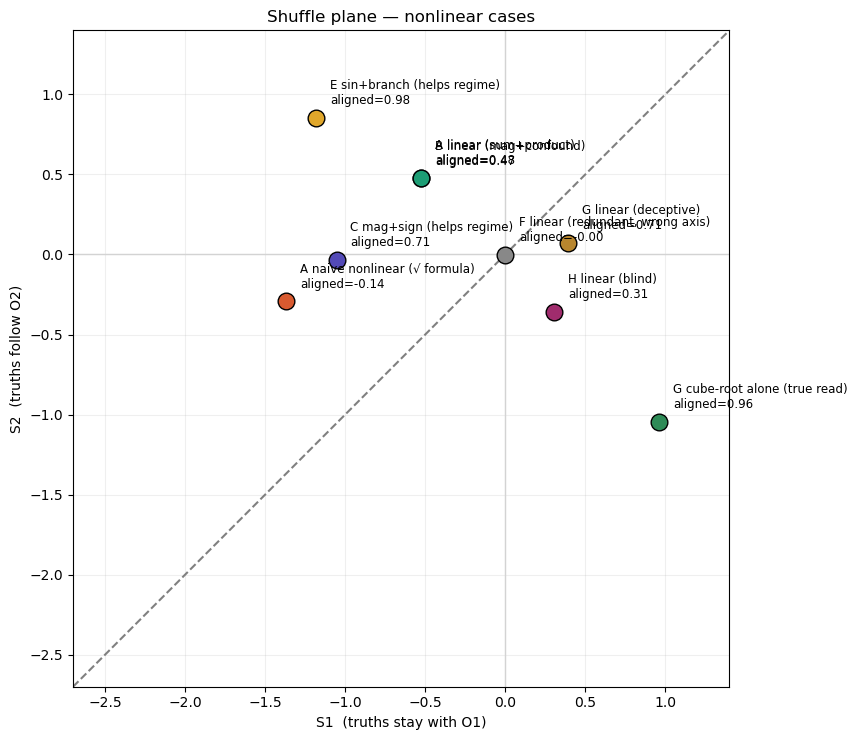

In [84]:
def shuffle_custom(estimator, o1, o2, truth, seed=0):
    """Same aligned/S1/S2 recipe as shuffle_signature, for an arbitrary (o1,o2)->theta1_hat estimator."""
    g = np.random.default_rng(seed)
    o1v, o2v, tv = o1[va], o2[va], truth[va]
    perm = g.permutation(len(tv))
    A = r2(tv, estimator(o1v, o2v))
    pred_shuf = estimator(o1v, o2v[perm])
    S1 = r2(tv, pred_shuf)             # truths stay with O1
    S2 = r2(tv[perm], pred_shuf)       # truths follow O2
    return A, S1, S2

def est_linear(W):
    return lambda o1v, o2v: predict(W, np.hstack([o1v, o2v]))

def est_naive_quadratic(o1v, o2v):
    s, p = o2v[:, 0], o1v[:, 0]
    disc = np.clip(s**2 - 4*p, 0, None)
    return (s + np.sqrt(disc)) / 2

def est_mag_sign(o1v, o2v):
    return np.sign(o2v[:, 0]) * np.sqrt(np.clip(o1v[:, 0], 0, None))

def est_sin_branch(o1v, o2v):
    asin_o1 = np.arcsin(np.clip(o1v[:, 0], -1, 1))
    branches = []
    for n in range(-4, 5):
        branches.append((asin_o1 + 2*np.pi*n) / k)
        branches.append((np.pi - asin_o1 + 2*np.pi*n) / k)
    branches = np.stack(branches, axis=1)
    diffs = np.abs(branches - o2v[:, 0:1])
    return branches[np.arange(len(o1v)), np.argmin(diffs, axis=1)]

def est_cbrt_alone(o1v, o2v):
    return np.cbrt(o1v[:, 0])   # ignores O2 entirely

oC1_rep = (t1**2 + sigma * g.normal(size=N)).reshape(-1, 1)
oC2_rep = (t1 + 0.8 * g.normal(size=N)).reshape(-1, 1)
oE1_rep = (np.sin(k * t1) + sigma_o1 * g.normal(size=N)).reshape(-1, 1)
oE2_rep = (t1 + 0.2 * g.normal(size=N)).reshape(-1, 1)

NONLINEAR_CASES = {
    "A linear (sum+product)":     (shuffle_custom(est_linear(WA), oA1, oA2, t1), "#185FA5"),
    "A naive nonlinear (√ formula)": (shuffle_custom(est_naive_quadratic, oA1, oA2, t1), "#D85A30"),
    "B linear (mag+confound)":    (shuffle_custom(est_linear(WB), oB1, oB2, t1), "#1D9E75"),
    "C mag+sign (helps regime)":  (shuffle_custom(est_mag_sign, oC1_rep, oC2_rep, t1), "#534AB7"),
    "E sin+branch (helps regime)": (shuffle_custom(est_sin_branch, oE1_rep, oE2_rep, t1), "#E0A72B"),
    "F linear (redundant, wrong axis)": (shuffle_custom(est_linear(WF), oF1, oF2, t1), "#888888"),
    "G linear (deceptive)":        (shuffle_custom(est_linear(WG), oG1, oG2, t1), "#B8862E"),
    "G cube-root alone (true read)": (shuffle_custom(est_cbrt_alone, oG1, oG2, t1), "#2E8B57"),
    "H linear (blind)":            (shuffle_custom(est_linear(WH), oH1, oH2, t1), "#A02C6D"),
}

fig, ax = plt.subplots(figsize=(8.5, 7.5))
lim = (-2.7, 1.4)
ax.plot(lim, lim, color="gray", ls="--", lw=1.5)
ax.axhline(0, color="lightgray", lw=1); ax.axvline(0, color="lightgray", lw=1)
print(f"{'case':<32}{'aligned':>9}{'S1':>8}{'S2':>8}")
for name, ((A, S1, S2), color) in NONLINEAR_CASES.items():
    ax.plot(S1, S2, "o", ms=12, color=color, mec="k")
    ax.annotate(f"{name}\naligned={A:.2f}", (S1, S2), xytext=(10, 10),
                textcoords="offset points", fontsize=8.5)
    print(f"{name:<32}{A:>9.2f}{S1:>8.2f}{S2:>8.2f}")
ax.set_xlabel("S1  (truths stay with O1)"); ax.set_ylabel("S2  (truths follow O2)")
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal"); ax.grid(alpha=0.2)
ax.set_title("Shuffle plane — nonlinear cases")
plt.tight_layout()
plt.show()

**A linear** and **B linear** land on nearly the same point — `(A≈0.48,
S1≈−0.52, S2≈0.48)` — because in both cases O1's linear weight is ~0 and O2
does all the work, so this is Experiment 3's Case 1 pattern *reflected*
(compare `(0.92, 0.92, −0.89)`): here it's O2, not O1, carrying everything,
so shuffling O2 destroys the aligned score instead of leaving it untouched.
**The point**: a purely linear shuffle test genuinely cannot distinguish Case
A from Case B — both look like "clean single-observable reliance on O2." The
fact that Case A secretly has recoverable information and Case B doesn't is
invisible from this diagnostic alone.

**A naive nonlinear** lands somewhere the linear categories never reach:
negative on *aligned itself* (−0.14), and asymmetrically negative on both S1
(−1.37) and S2 (−0.29). This is a distinct failure mode from anything in
Experiment 3 — not "no information" (Case 5, aligned≈0) and not "suppression"
(Cases 2/3, aligned still positive) but an estimator that is actively
unreliable even before any shuffling, because of the unresolved swap
ambiguity — and shuffling makes an already-bad estimator worse rather than
collapsing a good one.

**C and E** (both in their "helps" regime) land with strongly negative S1
and near-zero-to-positive S2 — the opposite asymmetry from A/B's linear
points. That makes sense: here O2 isn't a redundant confound, it's the
*disambiguator* — shuffle it and the precise-but-branch/sign-ambiguous O1
term gets paired with the wrong branch/sign for essentially every row, which
is worse than dropping O1 entirely (hence S1 well below 0, not just reduced).
Reading off "reliance on O1 vs O2" from position alone would call this
"relies only on O2" — true in the narrow sense that O2 supplies the bit that
breaks the tie, but it undersells that O1 is doing the actual precision work.

**F linear** sits right at the origin `(≈0,0,0)` — indistinguishable from
Case 5's "no information" on this plot, even though both observables
individually and jointly carry real information (about `θ1²`, R²≈0.96-0.98).
The shuffle plane, same as always, only sees signed-θ1 reliance — it's blind
to information that's real but off-target.

**G linear vs G cube-root** is the sharpest pair here: *identical* underlying
data, two different verdicts. The linear estimator lands at `(0.71, 0.39,
0.07)` — a real, if modest, positive reliance on O2. The cube-root-alone
estimator (which literally never reads O2) lands at `(0.96, 0.96, −1.03)` —
almost exactly Case 1's signature, because that's what it structurally is
once you fix the O1 readout. Both shuffle results are individually correct
about the model they were run on; neither is correct about "the observables"
in the abstract. The shuffle test measures a model's reliance, not a
property of the data — a lesson easy to miss when there's usually only one
obvious model (linear) to run it on.

**H linear** sits at `(0.31, 0.31, −0.35)` — small, and barely moved from
aligned by shuffling O2, because the linear fit's weight on O2 is ≈0 (it
can't see the `θ2²` relationship at all). The true nonlinear estimator (not
plotted, see above) does rely heavily on O2 — the blind linear view simply
can't show it.

## Experiment 5 (optional, needs torch) — same comparison with the real MLP

The linear analysis is exact for a linear readout; this checks the conclusions
hold for the actual ReLU `SimpleMLP`. Skipped automatically when torch is not
installed (e.g. running locally) — run on the cluster.

In [85]:
try:
    import sys, torch
    sys.path.append("../src")
    from models import SimpleMLP
    HAVE_TORCH = True
except ImportError:
    HAVE_TORCH = False
    print("torch not available — skipping the MLP check (run on the cluster)")

In [86]:
if HAVE_TORCH:
    def fit_mlp(Xtr, ytr, epochs=300, lr=1e-3, seed=0):
        torch.manual_seed(seed)
        net = SimpleMLP(Xtr.shape[1], [64, 32], 1, dropout_rate=0.0)
        opt = torch.optim.Adam(net.parameters(), lr=lr)
        Xt = torch.from_numpy(Xtr).float()
        yt = torch.from_numpy(ytr.reshape(-1, 1)).float()
        for _ in range(epochs):
            opt.zero_grad()
            loss = torch.nn.functional.mse_loss(net(Xt), yt)
            loss.backward()
            opt.step()
        net.eval()
        return net

    def run_mechanism_mlp(mech, nl, seed=0):
        g = np.random.default_rng(seed)
        z2_tr, z2_va = mech(x2, nl, g)
        # smaller subset — the MLP is slower than lstsq
        sub = slice(0, 8_000)
        net = fit_mlp(np.hstack([x1[sub], z2_tr[sub]]), theta[sub], seed=seed)
        with torch.no_grad():
            p = net(torch.from_numpy(np.hstack([x1[va], z2_va[va]])).float()).numpy().ravel()
        return r2(theta[va], p)

    print(f"{'noise':<8}" + "".join(f"{n:>12}" for n in MECHANISMS))
    for nl in [0, 1, 2.5, 5]:
        row = f"{nl:<8}"
        for name, (m, _, _) in MECHANISMS.items():
            row += f"{run_mechanism_mlp(m, nl):>12.3f}"
        print(row)
    print(f"\nlinear floor for reference: {floor:.3f}")

noise        current      renorm  noise_both    mix_both
0              0.964       0.964       0.964       0.964
1              0.742       0.963       0.419       0.506
2.5            0.486       0.962      -0.209       0.013
5              0.298       0.962      -0.544      -0.339

linear floor for reference: 0.627


## Adding a new mechanism

1. Write a function `(x, noise_level, rng) -> (train_version, val_version)`.
2. Add it to `MECHANISMS` with a color.
3. Re-run Experiment 1. If it should destroy O₂'s information, it must reach
   the O₁-alone floor; if it plateaus above, validation is still feeding the
   model usable signal from O₂.